Import the required libraries.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

Prepare the MNIST Dataset.

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # normalize to [-1, 1]
])

train_data = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_data = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=1000, shuffle=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 17.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 462kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.28MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.59MB/s]


Define the MLP Model.

In [3]:
class MLPClassifier(nn.Module):
    def __init__(self, activation_fn):
        super(MLPClassifier, self).__init__()
        self.flatten = nn.Flatten()
        self.layer1 = nn.Linear(28*28, 256)
        self.act1 = activation_fn
        self.layer2 = nn.Linear(256, 128)
        self.act2 = activation_fn
        self.output = nn.Linear(128, 10)  # 10 classes (digits)

    def forward(self, x):
        x = self.flatten(x)
        x = self.act1(self.layer1(x))
        x = self.act2(self.layer2(x))
        x = self.output(x)
        return x

Activation functions to compare: ReLU, Tanh, Sigmoid, LeakyReLU

In [4]:
activation_functions = {
    "ReLU": nn.ReLU(),
    "Tanh": nn.Tanh(),
    "Sigmoid": nn.Sigmoid(),
    "LeakyReLU": nn.LeakyReLU()
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


Training and Evaluation Function (returns model)

In [5]:

def train_and_evaluate(activation_name, activation_fn, epochs=5):
    print(f"\n{'='*20} Training with {activation_name} {'='*20}")
    model = MLPClassifier(activation_fn).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    # Training Loop
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {total_loss/len(train_loader):.4f}")

    # Evaluation
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    accuracy = 100 * correct / total
    print(f"Test Accuracy with {activation_name}: {accuracy:.2f}%")

    # Return accuracy and trained model
    return accuracy, model

Compare All Activation Functions.

In [6]:
results = {}
models = {}

for name, act in activation_functions.items():
    acc, trained_model = train_and_evaluate(name, act)
    results[name] = acc
    models[name] = trained_model


==================== Training with ReLU ====================
Epoch [1/5], Loss: 0.3426
Epoch [2/5], Loss: 0.1539
Epoch [3/5], Loss: 0.1141
Epoch [4/5], Loss: 0.0945
Epoch [5/5], Loss: 0.0772
Test Accuracy with ReLU: 96.92%

==================== Training with Tanh ====================
Epoch [1/5], Loss: 0.3100
Epoch [2/5], Loss: 0.1499
Epoch [3/5], Loss: 0.1220
Epoch [4/5], Loss: 0.1110
Epoch [5/5], Loss: 0.0992
Test Accuracy with Tanh: 96.18%

==================== Training with Sigmoid ====================
Epoch [1/5], Loss: 0.4950
Epoch [2/5], Loss: 0.1792
Epoch [3/5], Loss: 0.1216
Epoch [4/5], Loss: 0.0959
Epoch [5/5], Loss: 0.0763
Test Accuracy with Sigmoid: 96.97%

==================== Training with LeakyReLU ====================
Epoch [1/5], Loss: 0.3290
Epoch [2/5], Loss: 0.1451
Epoch [3/5], Loss: 0.1091
Epoch [4/5], Loss: 0.0901
Epoch [5/5], Loss: 0.0745
Test Accuracy with LeakyReLU: 96.79%


Plot Results

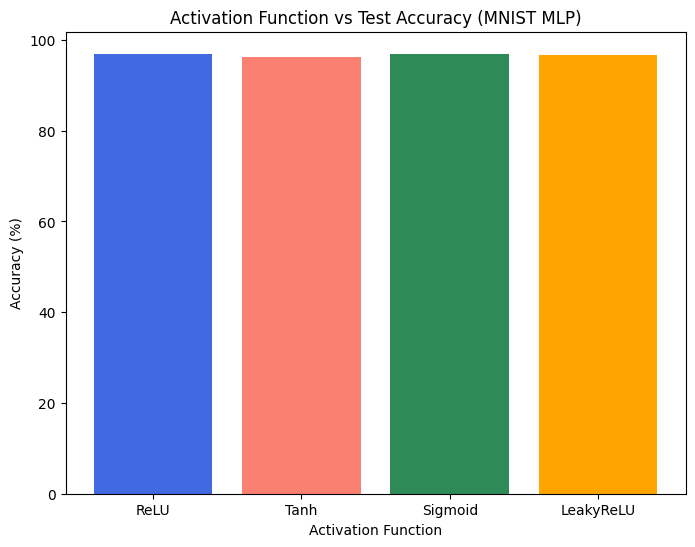

In [7]:
plt.figure(figsize=(8,6))
plt.bar(results.keys(), results.values(), color=['royalblue','salmon','seagreen','orange'])
plt.title("Activation Function vs Test Accuracy (MNIST MLP)")
plt.ylabel("Accuracy (%)")
plt.xlabel("Activation Function")
plt.show()

Visualize Predictions from the Best Model


==================== Visualizing Predictions for Sigmoid Model ====================


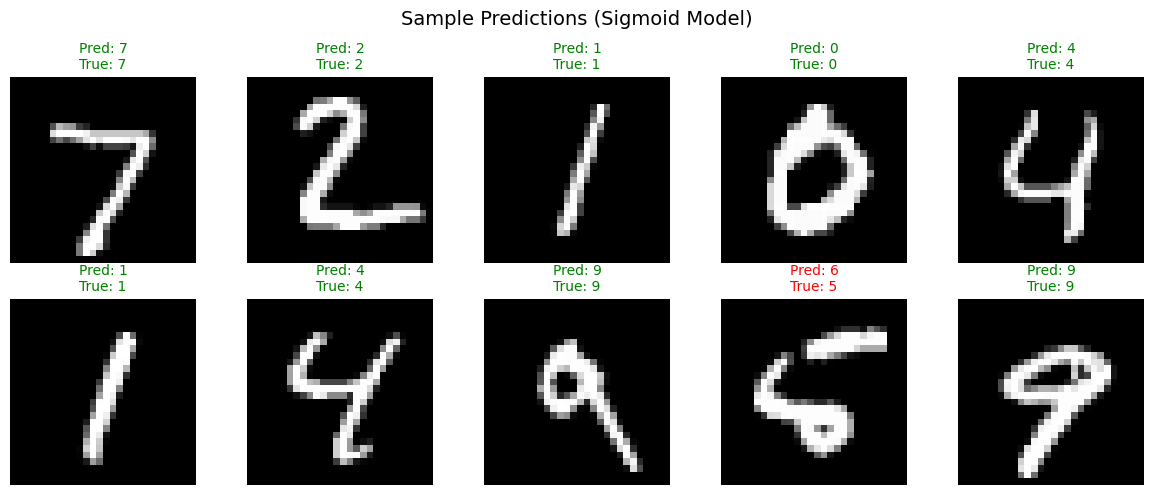

In [8]:
best_activation_name = max(results, key=results.get)
model = models[best_activation_name]
print(f"\n{'='*20} Visualizing Predictions for {best_activation_name} Model {'='*20}")

# Take one batch from the test set
images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)

# Get predictions
model.eval()
with torch.no_grad():
    outputs = model(images)
    _, preds = torch.max(outputs, 1)

# Show a few samples
plt.figure(figsize=(12, 5))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(images[i].cpu().reshape(28, 28), cmap="gray")
    pred_label = preds[i].item()
    true_label = labels[i].item()
    color = "green" if pred_label == true_label else "red"
    plt.title(f"Pred: {pred_label}\nTrue: {true_label}", color=color, fontsize=10)
    plt.axis("off")

plt.suptitle(f"Sample Predictions ({best_activation_name} Model)", fontsize=14)
plt.tight_layout()
plt.show()